### Essay Writer

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage

memory = MemorySaver()

### Agent State

In [3]:
class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int

In [4]:
from langchain_openai import ChatOpenAI
model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

d:\LangGraph\langgraph_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Prompts

In [5]:
PLAN_PROMPT = """You are an expert writer tasked with writing a high level outline of an essay. \
Write such an outline for the user provided topic. Give an outline of the essay along with any relevant notes \
or instructions for the sections."""

In [6]:
WRITER_PROMPT = """You are an essay assistant tasked with writing excellent 5-paragraph essays.\
Generate the best essay possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed: 

------

{content}"""

In [7]:
REFLECTION_PROMPT = """You are a teacher grading an essay submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc."""

In [8]:
RESEARCH_PLAN_PROMPT = """You are a researcher charged with providing information that can \
be used when writing the following essay. Generate a list of search queries that will gather \
any relevant information. Only generate 3 queries max."""


In [9]:
RESEARCH_CRITIQUE_PROMPT = """You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max."""


### Agents

In [10]:
from pydantic import BaseModel

class Queries(BaseModel):
    queries: List[str]

In [11]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun(
    name="search",
    region="us-en"
)

In [12]:
def plan_node(state: AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT), 
        HumanMessage(content=state['task'])
    ]
    response = model.invoke(messages)
    return {"plan": response.content}

In [13]:
def research_plan_node(state: AgentState):
    """Planner using duckgo"""
    print("=== START research_plan_node ===")
    
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ])
    
    if isinstance(queries, dict):
        queries_list = queries['queries']
    else:
        queries_list = queries.queries
    
    content = state.get('content', []) or [] 
    
    for q in queries_list:
        print(f"\n=== Processing query: {q} ===")
        english_query = f"{q} site:*.com OR site:*.org (english)"
        print(f"\n=== Processing query: {english_query} ===")
        try:
            response = search.run(english_query)
            content.append(response)
        except Exception as e:
            print(f"Search error for '{q}': {e}")
            content.append(f"Error searching for: {q}")
    
    print(f"=== END research_plan_node, returning {len(content)} items ===")
    return {"content": content}


In [14]:
def generation_node(state: AgentState):   
    """Generate the essay drafts"""
    content = "\n\n".join(state['content'] or [])
    user_message = HumanMessage(
        content=f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}")
    messages = [
        SystemMessage(
            content=WRITER_PROMPT.format(content=content)
        ),
        user_message
        ]
    response = model.invoke(messages)
    return {
        "draft": response.content, 
        "revision_number": state.get("revision_number", 1) + 1     #Counts the number of revisions
    }


In [15]:
def reflection_node(state: AgentState):
    """Get critique from the LLM on the draft"""
    messages = [
        SystemMessage(content=REFLECTION_PROMPT), 
        HumanMessage(content=state['draft'])
    ]
    response = model.invoke(messages)
    return {"critique": response.content}

In [16]:
def research_critique_node(state: AgentState):
    """Takes in critique and search, returns content"""
    print("=== START research_critique_node ===")
    print(f"State keys: {state.keys()}")
    
    # Check if critique exists
    critique = state.get('critique', '')
    if not critique:
        print("WARNING: No critique found in state")
        return {"content": state.get('content', [])}
    
    print(f"Critique: {critique[:200]}...")
    
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=critique)
    ])
    
    if isinstance(queries, dict):
        queries_list = queries['queries']
    else:
        queries_list = queries.queries
    
    content = state.get('content', []) or []
    
    for q in queries_list:
        print(f"\n=== Processing critique query: {q} ===")
        english_query = f"{q} site:*.com OR site:*.org (english)"
        print(f"\n=== Processing query: {english_query} ===")
        try:
            response = search.run(english_query)
            content.append(response)
        except Exception as e:
            print(f"Search error for '{q}': {e}")
            content.append(f"Error searching for: {q}")
    
    print(f"=== END research_critique_node, returning {len(content)} items ===")
    return {"content": content}

In [17]:
def should_continue(state):
    if state["revision_number"] > state["max_revisions"]:
        return END
    return "reflect"

### Graph

In [18]:
builder = StateGraph(AgentState)

In [19]:
"""Nodes"""
builder.add_node("planner", plan_node)
builder.add_node("generate", generation_node)
builder.add_node("reflect", reflection_node)
builder.add_node("research_plan", research_plan_node)
builder.add_node("research_critique", research_critique_node)

builder.set_entry_point("planner")

#Conditional edge
builder.add_conditional_edges(
    "generate", 
    should_continue, 
    {END: END, "reflect": "reflect"}
)
#Edges
builder.add_edge("planner", "research_plan")
builder.add_edge("research_plan", "generate")

builder.add_edge("reflect", "research_critique")
builder.add_edge("research_critique", "generate")

In [20]:
graph = builder.compile(checkpointer=memory)

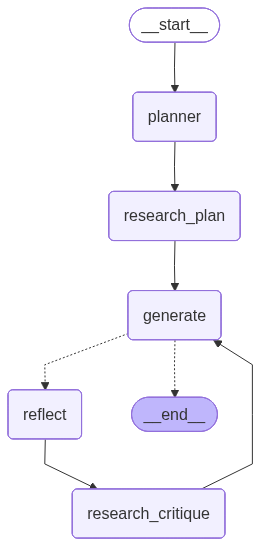

In [21]:
from IPython.display import Image, display

# Visualize with Mermaid (no pygraphviz needed)
display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
thread = {"configurable": {"thread_id": "1"}}
for s in graph.stream({
    'task': "what is the difference between langchain and langsmith",
    "max_revisions": 2,
    "revision_number": 1,
}, thread):
    print(s)

{'planner': {'plan': 'I. Introduction\n    A. Brief overview of Langchain and Langsmith\n    B. Thesis statement: Exploring the differences between Langchain and Langsmith\n\nII. Langchain\n    A. Definition and explanation\n    B. Key features and characteristics\n    C. Use cases and applications\n    D. Advantages and disadvantages\n\nIII. Langsmith\n    A. Definition and explanation\n    B. Key features and characteristics\n    C. Use cases and applications\n    D. Advantages and disadvantages\n\nIV. Comparison between Langchain and Langsmith\n    A. Technology stack\n    B. Scalability\n    C. Security\n    D. Interoperability\n    E. Performance\n\nV. Conclusion\n    A. Recap of main differences between Langchain and Langsmith\n    B. Implications for future developments in the field\n    C. Final thoughts on the significance of understanding these differences'}}
=== START research_plan_node ===


d:\LangGraph\langgraph_env\Lib\site-packages\langchain_openai\chat_models\base.py:2018: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(



=== Processing query: difference between langchain and langsmith ===

=== Processing query: difference between langchain and langsmith site:*.com OR site:*.org (english) ===

=== Processing query: langchain overview ===

=== Processing query: langchain overview site:*.com OR site:*.org (english) ===

=== Processing query: langsmith overview ===

=== Processing query: langsmith overview site:*.com OR site:*.org (english) ===
=== END research_plan_node, returning 3 items ===
{'research_plan': {'content': ["package com . langchain .example.rag; import lombok.extern.slf4j.Slf4j; import java.util.Scanner LangChain 4j is fundamentally different from LangChain — not just in API design, but in mindset. LangChain ’s evolution went from Chains → Runnables → StateGraphs. The new tokenizer significantly improves the encoding of Chinese, Japanese and Korean text, at the expense of a slight increase of the token counts for English and Code. For the curious mind, here is the technical report on Gemm